<a href="https://colab.research.google.com/github/BandanaSingha24/FOUNDATION-OF-Python-and-ML/blob/main/Python%20Foundation%20For%20Bioinformatics/%20TCGA%20_Breast%20_Cancer_MMP11_Gene_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
df=pd.read_csv("/content/data.csv")
df.head()

,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p27.pT198,pp_p38.MAPK,pp_p38.pT180.Y182,pp_p53,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.043330,-0.002598,0.449228,-0.375230,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,-0.220764,0.220809,1.035115,-0.074136,0.279067,0.292925,-0.155242,-0.089365,0.267530,0
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.010615,-0.133214,0.344969,-0.351936,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,0.064070,-0.384008,0.678042,0.096329,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.065488,0.209858,0.920408,0.042210,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0


In [85]:
print(df.columns.tolist()[:15])

['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B', 'rs_S100A7', 'rs_HMGCS2', 'rs_CYP2B7P1', 'rs_ANKRD30A', 'rs_PRAME']


In [88]:
df=pd.read_csv("/content/data.csv")
single_gene_mean=df["rs_CLEC3A"].mean()
print(single_gene_mean)

4.5471968163390155


In [ ]:
high_expression_df=df[df["rs_CLEC3A"]>4.54]
print(high_expression_df.shape)

(269, 1937)


In [ ]:
all_genes_mean=df.mean()
top_10_genes=all_genes_mean.sort_values(ascending=False).head(10)
print(top_10_genes)

rs_MMP11     11.601131
rs_ESR1      11.555291
rs_APOD      11.482519
rs_FOXA1     11.443274
rs_AGR2      11.350099
rs_LTF       11.297901
rs_GFRA1     10.976432
rs_CXCL14    10.899509
rs_SCUBE2    10.752147
rs_SPDEF     10.742211
dtype: float64


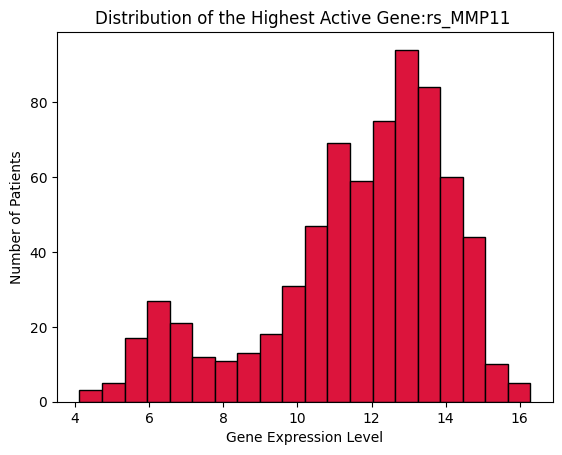

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["rs_MMP11"],bins=20,color="crimson",edgecolor="black")
plt.title("Distribution of the Highest Active Gene:rs_MMP11 ")
plt.xlabel("Gene Expression Level")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
import numpy as np
mmp11_array=df["rs_MMP11"].values
log_mmp11=np.log2(mmp11_array+1)
print(mmp11_array[:5])
print(log_mmp11[:5])

[10.74546963 13.78481485 12.27615992  9.20951112 13.93861251]
[3.55403249 3.88604427 3.73076601 3.35184188 3.90097425]


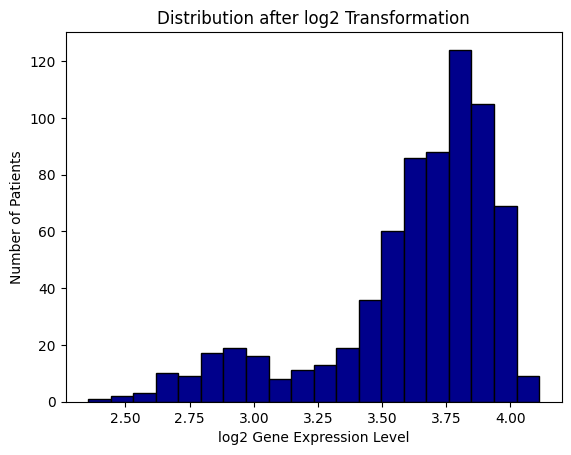

In [ ]:
plt.hist(log_mmp11,bins=20,color="darkblue",edgecolor="black")
plt.title("Distribution after log2 Transformation")
plt.xlabel("log2 Gene Expression Level")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
print(np.mean(log_mmp11))
print(np.median(log_mmp11))
print(np.std(log_mmp11))

3.6202113024322227
3.725804820111947
0.33636163099444155


In [ ]:
def analyze_gene(gene_data, gene_name):
      print(f"---Analysis for {gene_name}---")
      print(f"Mean:{np.mean(gene_data):.4f}")
      print(f"Median:{np.median(gene_data):.4f}")
      print(f"Standard Deviation:{np.std(gene_data):.4f}")
analyze_gene(log_mmp11,"MMP11")

---Analysis for MMP11---
Mean:3.6202
Median:3.7258
Standard Deviation:0.3364


In [92]:
analyze_gene(df["rs_ESR1"],"rs_ESR1")

---Analysis for rs_ESR1---
Mean:11.5553
Median:12.5513
Standard Deviation:3.0714


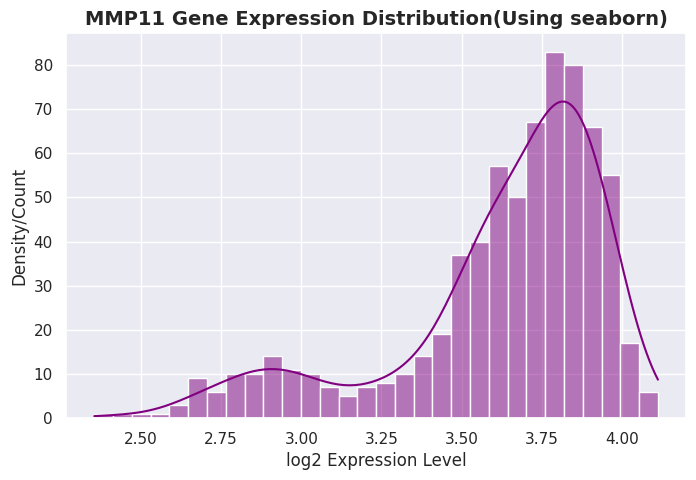

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.set_theme(style="darkgrid")
sns.histplot(log_mmp11,kde=True,color="purple",bins=30)
plt.title("MMP11 Gene Expression Distribution(Using seaborn)",fontsize=14,fontweight="bold")
plt.xlabel("log2 Expression Level",fontsize=12)
plt.ylabel("Density/Count",fontsize=12)
plt.show()

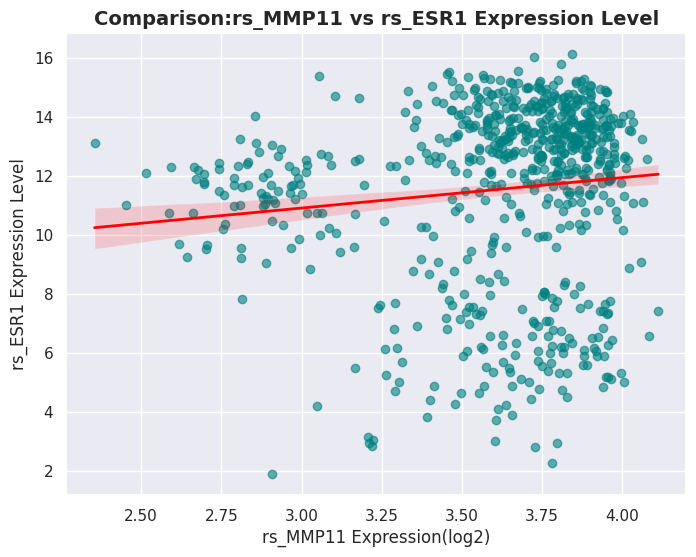

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.set_theme(style="darkgrid")
sns.regplot(x=log_mmp11,y=df["rs_ESR1"],color="teal",scatter_kws={"alpha":0.6,"color":"teal"},line_kws={"color":"red","linewidth":2})
plt.title("Comparison:rs_MMP11 vs rs_ESR1 Expression Level",fontsize=14,fontweight="bold")
plt.xlabel("rs_MMP11 Expression(log2)",fontsize=12)
plt.ylabel("rs_ESR1 Expression Level",fontsize=12)
plt.show()

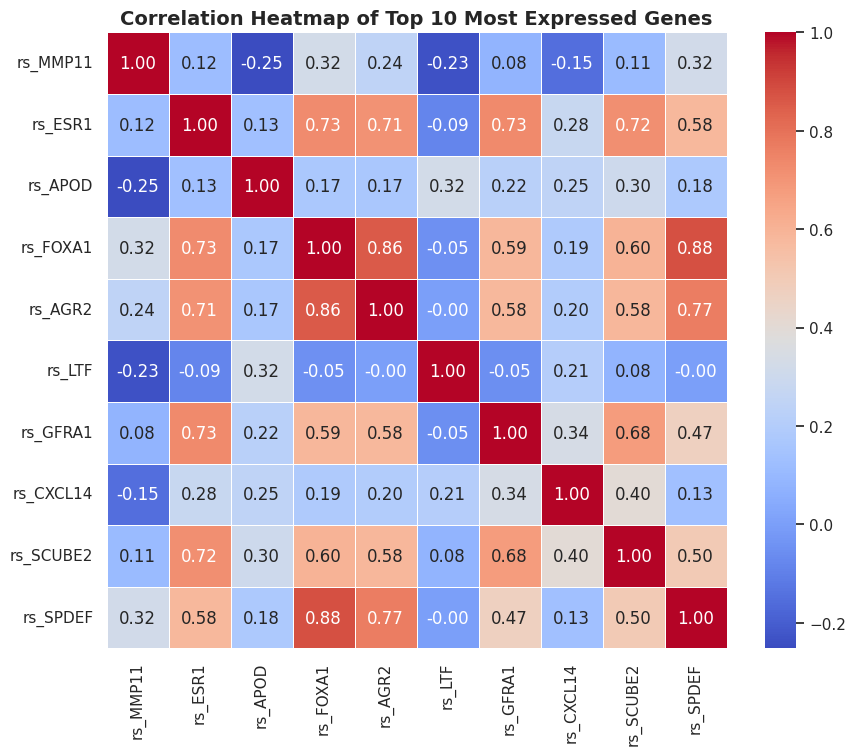

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
top_10_genes_list=["rs_MMP11","rs_ESR1",
                   "rs_APOD","rs_FOXA1",
                   "rs_AGR2","rs_LTF",
                    "rs_GFRA1","rs_CXCL14",
                    "rs_SCUBE2","rs_SPDEF"]
my_top_10_data=df[top_10_genes_list]
my_corr=my_top_10_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(my_corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of Top 10 Most Expressed Genes",fontsize=14,fontweight="bold")
plt.show()